In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from tqdm import tqdm

**Loading my processed data**

In [2]:
X = np.load("/kaggle/input/datasets/abhishekpriya/data-processing/X_all.npy")
Y = np.load("/kaggle/input/datasets/abhishekpriya/data-processing/Y_all.npy")

print(X.shape)
print(Y.shape)

(2996, 1920)
(2996,)


**CWT parameters**

In [3]:
fs = 64

wavelet = 'morl'

scales = np.arange(1, 129)

Generate one CWT image

In [4]:
signal = X[0]

coefficients, frequencies = pywt.cwt(
    signal,
    scales,
    wavelet,
    sampling_period=1/fs
)

print(coefficients.shape)

(128, 1920)


Visualize the CWT

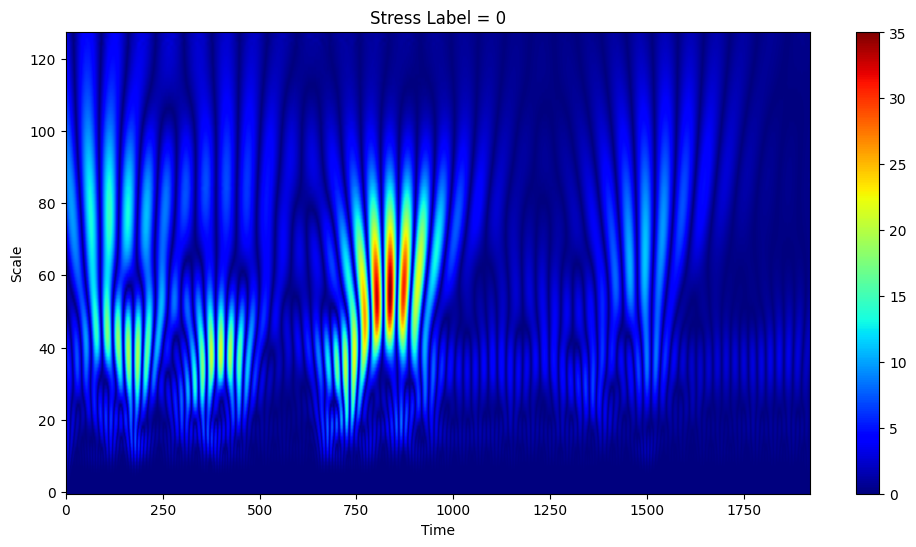

In [5]:
plt.figure(figsize=(12,6))

plt.imshow(
    np.abs(coefficients),
    aspect='auto',
    cmap='jet',
    origin='lower'
)

plt.colorbar()

plt.title(f"Stress Label = {Y[0]}")

plt.xlabel("Time")

plt.ylabel("Scale")

plt.show()

**Convert all windows**

In [6]:
X_cwt = []

for signal in tqdm(X):

    coeffs, _ = pywt.cwt(
        signal,
        scales,
        wavelet,
        sampling_period=1/fs
    )

    X_cwt.append(np.abs(coeffs))

100%|██████████| 2996/2996 [02:13<00:00, 22.47it/s]


Convert to NumPy

In [7]:
X_cwt = np.array(X_cwt)

print(X_cwt.shape)

(2996, 128, 1920)


**Normalize CWT images**

In [8]:
X_cwt = X_cwt.astype(np.float32)

mins = X_cwt.min(axis=(1,2), keepdims=True)
maxs = X_cwt.max(axis=(1,2), keepdims=True)

X_cwt = (X_cwt - mins) / (maxs - mins + 1e-8)

**Add channel dimension**

In [9]:
X_cwt = X_cwt[..., np.newaxis]

print(X_cwt.shape)

(2996, 128, 1920, 1)


**Verify a few samples**

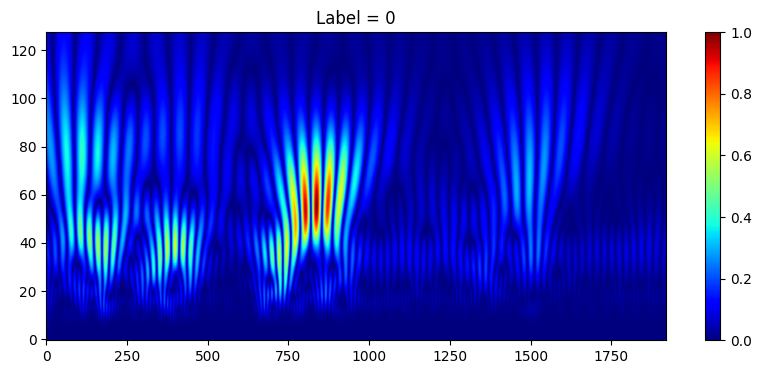

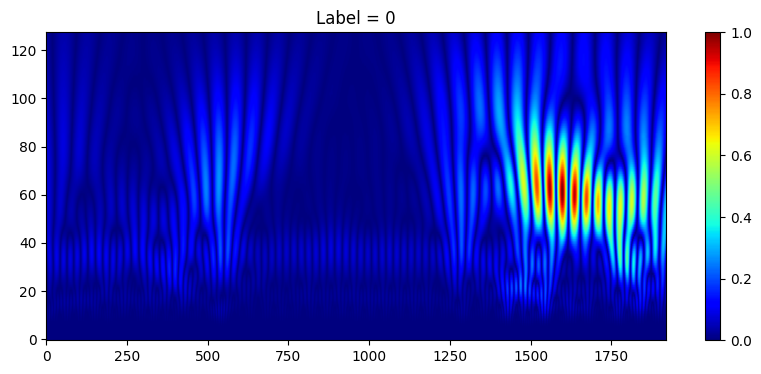

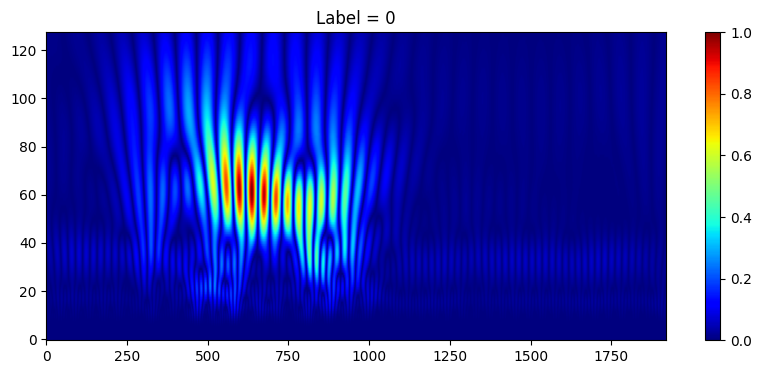

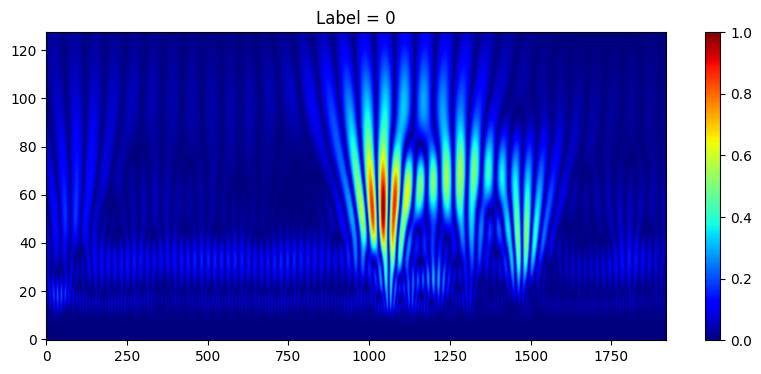

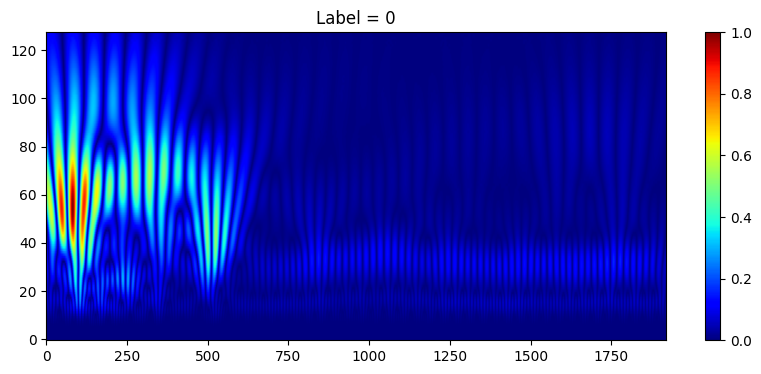

In [10]:
for i in range(5):

    plt.figure(figsize=(10,4))

    plt.imshow(
        X_cwt[i].squeeze(),
        aspect='auto',
        cmap='jet',
        origin='lower'
    )

    plt.title(f"Label = {Y[i]}")

    plt.colorbar()

    plt.show()

In [11]:
print("CWT Shape:", X_cwt.shape)
print("Labels Shape:", Y.shape)

print("Class Distribution:")
print(np.unique(Y, return_counts=True))

CWT Shape: (2996, 128, 1920, 1)
Labels Shape: (2996,)
Class Distribution:
(array([0, 1]), array([2329,  667]))


Resize Images

In [12]:
import tensorflow as tf
from tqdm import tqdm

X_resized = []

for img in tqdm(X_cwt):

    resized = tf.image.resize(img, (224,224))

    X_resized.append(resized.numpy())

X_resized = np.array(X_resized)

print(X_resized.shape)

  0%|          | 0/2996 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1782953040.059171      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782953040.061904      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
100%|██████████| 2996/2996 [00:06<00:00, 493.89it/s]


(2996, 224, 224, 1)


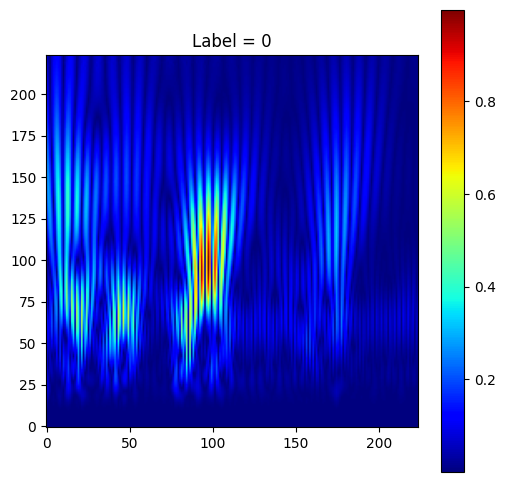

In [13]:
#verifying
plt.figure(figsize=(6,6))

plt.imshow(X_resized[0].squeeze(),
           cmap='jet',
           origin='lower')

plt.title(f"Label = {Y[0]}")

plt.colorbar()

plt.show()

**Train test split**

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_resized,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [15]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2097, 224, 224, 1)
(449, 224, 224, 1)
(450, 224, 224, 1)


In [16]:
print(np.unique(y_train,return_counts=True))
print(np.unique(y_val,return_counts=True))
print(np.unique(y_test,return_counts=True))

(array([0, 1]), array([1630,  467]))
(array([0, 1]), array([349, 100]))
(array([0, 1]), array([350, 100]))


**class weight**

In [17]:
from sklearn.utils.class_weight import compute_class_weight
# Compute automatic weights (for reference)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print("Automatic class weights:", dict(enumerate(weights)))

# Use manually tuned weights for training
class_weights = {
    0: 1.0,
    1: 3.0
}

print("Using class weights:", class_weights)

Automatic class weights: {0: np.float64(0.6432515337423312), 1: np.float64(2.2451820128479656)}
Using class weights: {0: 1.0, 1: 3.0}


In [18]:
import tensorflow as tf
BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train,y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val,y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test,y_test)
)

In [19]:
train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [20]:
for images,labels in train_ds.take(1):

    print(images.shape)
    print(labels.shape)

(16, 224, 224, 1)
(16,)


In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers

# -----------------------------
# Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

# -----------------------------
# Input
# -----------------------------
inputs = Input(shape=(224,224,1))

# Apply augmentation ONLY during training
x = data_augmentation(inputs)

# =============================
# Block 1
# =============================
x = Conv2D(
    32,
    (3,3),
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# =============================
# Block 2
# =============================
x = Conv2D(
    64,
    (3,3),
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.20)(x)

# =============================
# Block 3
# =============================
x = Conv2D(
    128,
    (3,3),
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.30)(x)

# =============================
# Block 4
# =============================
x = Conv2D(
    256,
    (3,3),
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.40)(x)

# =============================
# Classification Head
# =============================
x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(x)

x = BatchNormalization()(x)
x = Dropout(0.50)(x)

x = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(x)

x = Dropout(0.30)(x)

outputs = Dense(
    2,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,66

 Total params: 589,314 (2.25 MB)

 Trainable params: 587,330 (2.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [22]:
#compile
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
#callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

**Training**

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/60


E0000 00:00:1782953053.994560      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6626 - loss: 1.8282
Epoch 1: val_accuracy improved from None to 0.77728, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.6862 - loss: 1.6371 - val_accuracy: 0.7773 - val_loss: 1.0655 - learning_rate: 3.0000e-04
Epoch 2/60
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7327 - loss: 1.4739
Epoch 2: val_accuracy did not improve from 0.77728
132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7315 - loss: 1.4116 - val_accuracy: 0.7773 - val_loss: 1.7983 - learning_rate: 3.0000e-04
Epoch 3/60
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7617 - loss: 1.2752
Epoch 3: val_accuracy did not improve from 0.77728
132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7663 - loss: 1.2663 - val_accuracy: 0.7773 - val_loss: 3.0030 - learning_rate: 3.0000e-04
Epoch 4/60
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7854 -

In [25]:
y_prob = model.predict(test_ds)

y_pred = (y_prob[:,1] >= 0.35).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [26]:
y_true = np.concatenate(
    [y for _, y in test_ds],
    axis=0
)

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       350
           1       0.75      0.85      0.79       100

    accuracy                           0.90       450
   macro avg       0.85      0.88      0.87       450
weighted avg       0.91      0.90      0.90       450



In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[321  29]
 [ 15  85]]


In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print(np.unique(y_pred, return_counts=True))

Accuracy: 0.9022222222222223
(array([0, 1]), array([336, 114]))


In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])

roc_auc = auc(fpr, tpr)

print("AUC =", roc_auc)

AUC = 0.9567142857142857


In [31]:
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([336, 114]))
